# Day 5 — Supervised-Learning Mini-Project

An end-to-end pipeline on the Titanic dataset: EDA, preprocessing without data leakage, training and comparing three classifiers against a baseline, and selecting the best model.

## Step 1 — Choosing the Dataset and the Task Type

The dataset is the Titanic passenger list, and the goal is to predict Survived (0 or 1) from passenger attributes. Since the target is a category with exactly two possible values, not a continuous number, **this is a classification task**, not regression — so the appropriate models are classifiers (Logistic Regression, Random Forest, SVM).

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Step 2 — Brief EDA and Preprocessing
Load the dataset and inspect its shape, structure, descriptive statistics, and missing values.

In [23]:
df =pd.read_csv("Titanic-Dataset.csv")
print (df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The dataset has 891 rows and 12 columns, covering each passenger's class, name, sex, age, family aboard, fare, and survival outcome.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


.info() shows Age, Cabin, and Embarked have fewer non-null entries than the rest — confirmed with an exact count next.

In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


.describe() confirms shows a wide range in Fare, which will need scaling later since it's on a very different range from features like Pclass.

In [26]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

.isna().sum() shows the exact gaps: Age is missing 177 values, Cabin is missing 687 (the large majority of rows), and Embarked is missing 2.

In [27]:
df["Age"] = df["Age"].fillna( df["Age"].median())
df.dropna(subset=["Embarked"], inplace=True)
df = df.drop("Cabin" , axis =1)
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Handling the missing values:** Age is filled with its median (a common, minimally-biasing choice for a right-skewed numeric column); the 2 rows missing Embarked are dropped, since that's a negligible loss of data; and Cabin is dropped entirely, since it's missing for over 77% of passengers.

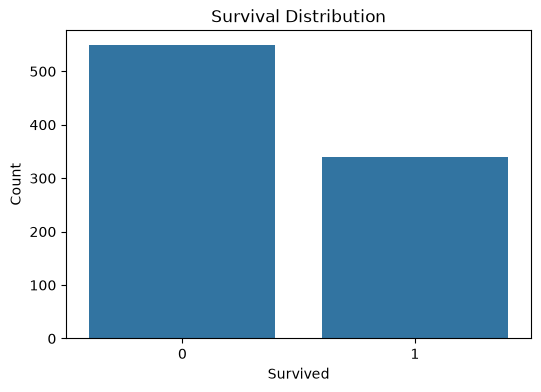

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

The count plot shows more passengers did not survive than did — a moderate class imbalance.

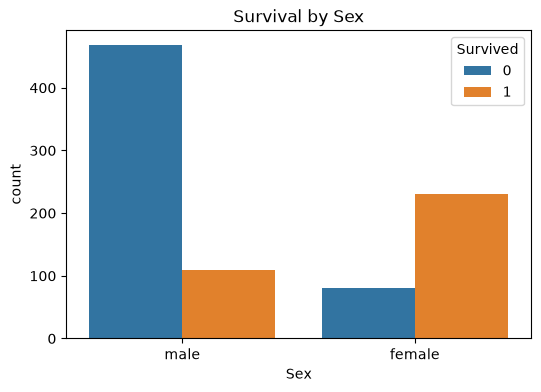

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival by Sex")

plt.show()

Survival by sex shows a stark split: most female passengers survived, while most male passengers did not — Sex is likely to be one of the strongest predictors in the model.

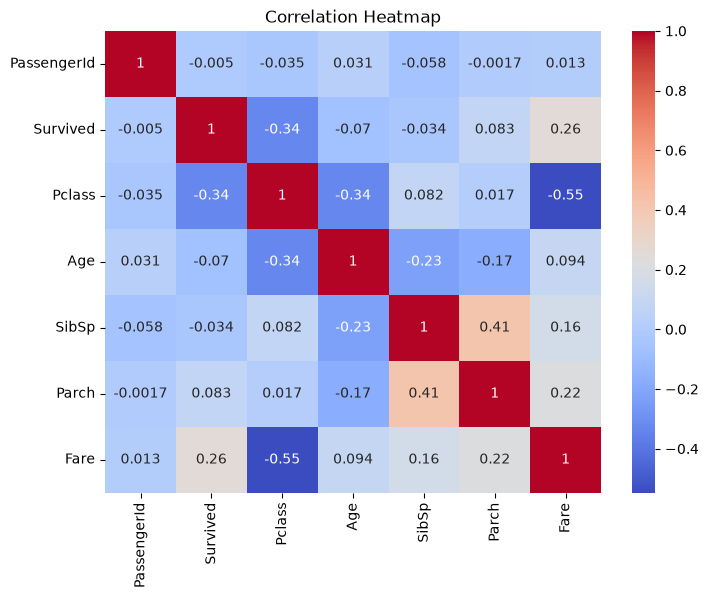

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap gives an early numeric hint of what the bar chart above showed visually, plus how Pclass, Fare, features relate to Survived and to each other.

In [31]:
df.drop( columns=["PassengerId","Name", "Ticket" ],    inplace=True, )

PassengerId, Name, and Ticket are dropped — none of them carry generalizable predictive signal (an ID number, a free-text name, and a ticket code are not meaningful numeric features for a model).

In [32]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df = pd.get_dummies(
    df,
    columns=["Embarked"]
)

Sex is mapped to numeric (male → 0, female → 1), and Embarked is one-hot encoded into separate 0/1 columns — both needed since models only accept numeric input.

In [33]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X holds every remaining column except Survived; y holds the target.

In [34]:
X_train , X_test , y_train ,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

An 80/20 train/test split is performed with random_state=42 fixed for reproducibility.

In [35]:
numeric_cols = ["Age", "Fare"]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols])

**Avoiding data leakage:** the scaler is fit only on X_train's Age and Fare columns, then only transformed (never re-fit) on X_test. Fitting on the full dataset — or on the test set — would let information about the test data leak into training and make the evaluation dishonestly optimistic.

## Step 3 — Training Models and Evaluating Against a Baseline
First establish a baseline — predicting the majority class for every row — then train and evaluate three real classifiers against it using the same metric.

In [36]:

baseline_pred = [y_train.mode()[0]] * len(y_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6123595505617978


**Baseline accuracy ≈ 61.2%** — this is what predicting "did not survive" for every single passenger would score, since that's the majority class. Any real model needs to clear this bar by a meaningful margin to prove it's learned something useful.

In [37]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)
print("Training done")

Training done


A Logistic Regression model is trained on the scaled, encoded training data.

Accuracy: 0.7808988764044944
              precision    recall  f1-score   support

           0       0.85      0.78      0.81       109
           1       0.69      0.78      0.73        69

    accuracy                           0.78       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.79      0.78      0.78       178



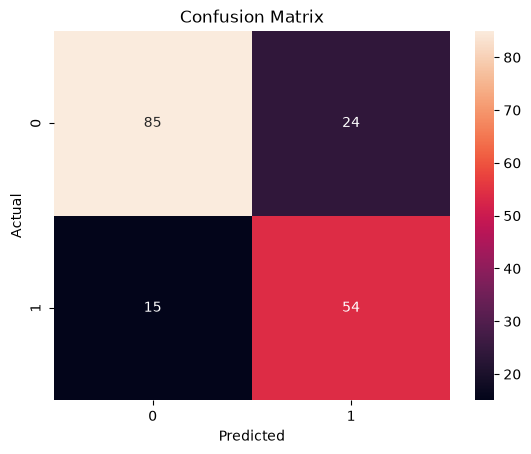

In [38]:
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report( y_test,y_pred_log))

cm = confusion_matrix(
    y_test,
    y_pred_log
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Logistic Regression: accuracy ≈ 78.1%**, comfortably above the 61.2% baseline. Precision/recall for class 1 (survived) are 0.69/0.78 — it catches most true survivors.

Accuracy: 0.7752808988764045
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       109
           1       0.69      0.75      0.72        69

    accuracy                           0.78       178
   macro avg       0.76      0.77      0.77       178
weighted avg       0.78      0.78      0.78       178



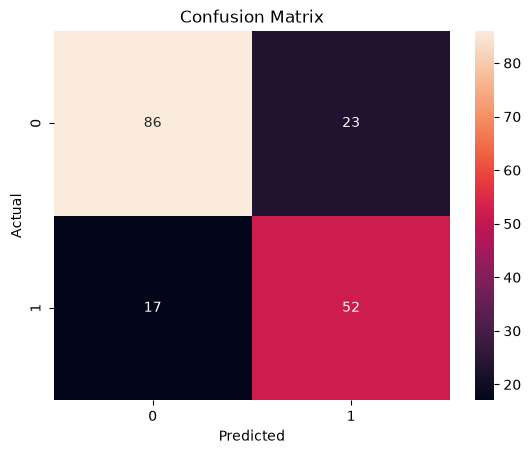

In [39]:
forest_model = RandomForestClassifier(n_estimators = 40, random_state=42)

forest_model.fit(
    X_train,
    y_train
)

y_pred_forest = forest_model.predict(X_test)

print( "Accuracy:", accuracy_score(y_test, y_pred_forest))

print(classification_report(y_test,y_pred_forest))

cm = confusion_matrix(
    y_test,
    y_pred_forest
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Random Forest: accuracy ≈ 77.5%**, essentially tied with logistic regression and, notably, slightly *lower* here — the extra flexibility of an ensemble doesn't automatically help on a smaller, simpler tabular dataset like this one (891 rows).

Accuracy: 0.8202247191011236
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       109
           1       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



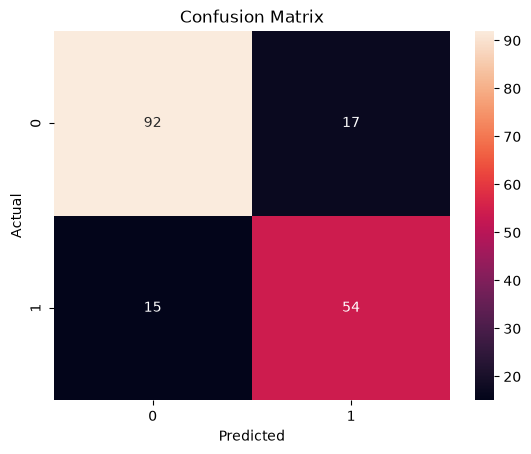

In [40]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)
svm_model.fit(
    X_train,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test
)
print( "Accuracy:", accuracy_score(y_test, y_pred_svm))

print(classification_report( y_test, y_pred_svm))

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


**SVM: accuracy ≈ 82.0%**, the best of the three, with the best precision, recall, and F1 for both classes as well (0.86/0.84 for class 0, 0.76/0.78 for class 1). The RBF kernel's ability to draw a curved decision boundary appears to fit this dataset's structure better than the other two models.

In [41]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        0.612,
        0.781,
        0.775,
        0.820
    ]
})

results

,Model,Accuracy
0,Baseline,0.612
1,Logistic Regression,0.781
2,Random Forest,0.775
3,SVM,0.820


All four results side by side confirm the ranking numerically: **Baseline (0.612) < Random Forest (0.775) ≈ Logistic Regression (0.781) < SVM (0.820)**. Every real model clears the baseline by a wide margin, and SVM is the clear top performer.

## Step 4 — Selecting and Justifying the Best Model

**SVM is the best-performing model for this task**, with the highest accuracy (0.820) and the best precision, recall, and F1 on both classes among the three models tried. It beats the 0.612 baseline by roughly 21 percentage points — clear evidence it has learned a genuinely useful relationship between passenger attributes and survival, not just memorized the majority class.

**Full pipeline recap:** raw Titanic data → EDA (missing values, class imbalance, sex/survival split, correlations) → preprocessing (median/mode imputation, dropping Cabin, encoding Sex/Embarked, scaling Age/Fare fit on train only) → 80/20 split → three models trained and evaluated against a 61.2% baseline → SVM selected as the best model at 82.0% accuracy.